Ноутбук служит основой для изучения, однако многое нужно будет поискать и почитать самостоятельно
***

# Часть 1 (6+ pt)

В этом домашнем задании вы познакомитесь с **разведовательным анализом** (EDA). На самом деле, разведывательный анализ — это не что-то съверхестественное. Более того, в предыдущих заданиях вы уже в какой-то мере его совершали.

**EDA (Exploratory Data Analysis)** — это первый и критически важный этап работы с данными, на котором вы «знакомитесь» с набором данных через визуализации и статистические резюме. Через EDA:
> - Обнаруживаете аномалии и пропуски
> - Понимаете распределение признаков
> - Выявляете взаимосвязи между переменными
> - Формулируете гипотезы для дальнейшей проверки

Звучит знакомо, правда?

Поэтому в этой домашке мы скорее соберем все навыки воедино и дополним их **статистикой** и **визуализацией**!

Будем руководствоваться следующими вопросами:
* Как распределены значения признаков?
* Какие признаки связаны между собой?
* Какие закономерности скрыты в данных?
* Какие гипотезы можно сформулировать для дальнейшего анализа?

В ноутбуке как всегда будут теоретические справки, но полезно еще почитать [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7),
[Understanding Correlation](https://seaborn.pydata.org/examples/many_pairwise_correlations.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7),
[Pandas Statistical Functions](https://pandas.pydata.org/docs/reference/general_functions.html?spm=a2ty_o01.29997173.0.0.33be5171FMA4h7#computational-descriptive-stats).

***
В этой части будем использовать датасет `diamonds` из `seaborn` (значения столбцов можно посмотреть в интернетах). Мы уже умеем загружать такие датасеты, сделаем это.

In [1]:
# Возможно вам нужно установить библиотеки

%pip install matplotlib.pyplot

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print(f"Pandas version: {pd.__version__}")
print(f"Seaborn version: {sns.__version__}")

Pandas version: 3.0.1
Seaborn version: 0.13.2


In [3]:
diamonds = sns.load_dataset('diamonds')
diamonds.shape

(53940, 10)

### Знакомство с данными (1 pt)

**ЗАДАНИЕ: базово исследуйте и очистите данные, напишите небольшой вывод.**

Можете ориентироваться на следующие важные пункты:
* Столбцы, их значение и типы их значений
* Количество уникальных значений
* Границы значений
* Пропуски
* Дубликаты

In [4]:
diamonds.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
print("типы данных:\n",diamonds.dtypes)

типы данных:
 carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object


Датасет содержит как числовые признаки (вес, цена, размеры), так и категориальные признаки (качество огранки, цвет и чистота).

In [6]:
print("количество уникальных значений:\n", diamonds.nunique())

количество уникальных значений:
 carat        273
cut            5
color          7
clarity        8
depth        184
table        127
price      11602
x            554
y            552
z            375
dtype: int64


In [7]:
print("пропуски")

diamonds.isna().sum()

пропуски


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Явных (Nan) пропусков нет, но могут быть нули, которые по логике не могут быть в данных, на это надо делать отдельную проверку.

In [8]:
print("дубликаты\n", diamonds.duplicated().sum())

diamonds = diamonds.drop_duplicates()

дубликаты
 146


В датасете обнаружено 146 полностью повторяющихся строк, которые были удалены.

In [9]:
print("базовые характеристики:\n")
diamonds.describe() 

базовые характеристики:



,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [10]:
(diamonds[['x','y','z']] == 0).sum()

median_x = diamonds.loc[diamonds['x'] > 0, 'x'].median()
median_y = diamonds.loc[diamonds['y'] > 0, 'y'].median()
median_z = diamonds.loc[diamonds['z'] > 0, 'z'].median()

diamonds['x'] = diamonds['x'].replace(0, median_x)
diamonds['y'] = diamonds['y'].replace(0, median_y)
diamonds['z'] = diamonds['z'].replace(0, median_z)

(diamonds[['x','y','z']] == 0).sum()

x    0
y    0
z    0
dtype: int64

После просмотра базовых характеристик, видим, что в размерах x y z есть нули, но это фзически невозможно, потому что x y z показывают длину, ширину и высоту. Сначала я посомтрела на кол-во таких строк, где эти значения нулевые, их немного, точно меньше 40, по сравнению с тем, сколько всего строк, как будто бы их можно было и вовсе удалить, но потом я решила заменить значения на медиану. Вопрос: в таких случаях корректно строки просто удалять?  

In [11]:
(diamonds[['x','y','z']] <= 0).sum()
(diamonds['carat'] <= 0).sum()
(diamonds['price'] <= 0).sum()

np.int64(0)

Проверили, что нет отрицательных значений

 Для веса (carat) и цены (price) выбросы отражают редкие, но реальные данные, потому что, бриллианты могут быть как и дешевыми, так и очень дорогими. То же самое с каратами, они могут быть как и маленькие, так и большие, это один из показателей того, насколько дорогим бриллиант будет. После обработки датасет готов для дальнейшего анализа и построения закономерностей.

**ВЫВОД:**
В ходе предварительного анализа данных были изучены типы столбцов, количество уникальных значений и статистические характеристики признаков. Было обнаружено наличие нулевых значений в столбцах размеров (x, y, z), которые были заменены медианными значениями. Выбросы в carat и price я пока не решила обрабатывать, мне кажется, они требуют более глубокого анализа.


### Одномерный анализ (3 pt)

После того, как вы «окинули взглядом» данные и применили те методы, которые уже знаете, перейдем к статистическому анализу и более глубокому пониманию.

В этом пункте мы поговорим про **одномерный анализ**, то есть про анализ каждого признака по отдельности _(можно найти и другие определения, не претендую на единсвенно верное)_.

Важными для одномерного анализа являются **мера центральности** и **мера разброса**, а также сама форма распределений. Давайте поговорим про них по отдельности.

***
Центрирование данных можно описать через три ключевые меры:
| Мера | Функция | Когда использовать |
| ---- | ------- | ------------------ |
| **Среднее** | `.mean()` | Для симметричных распределений без выбросов |
| **Медиана** | `.median()` | Для асимметричных распределений или при наличии выбросов |
| **Мода** (наиболее частое значение) | `.mode()` | Для категориальных данных или мультимодальных распределений |

Все три меры, безусловно, дают нам информацию о распределении данных и мы можем делать из этого выводы (например если среднее сильно отличается от медианы). Однако пукнт _«Когда использовать»_ говорит о том, когда эту меру стоит использовать для информативного описания распределения в дальнейшем (или для использования статистики при каких-то вычислениях).

In [12]:
# ЗАДАНИЕ:
#          1. Рассчитайте подходящие статистики для каждого из столбцов.
#          2. Объясните расхождения между средним и медианой, если такие есть.
#          3. Напишите вывод (ваши гипотезы) о распределении данных на основе мер центральности.

# Центральные меры
mean_values = diamonds.mean(numeric_only=True)      # среднее для числовых столбцов
median_values = diamonds.median(numeric_only=True)  # медиана для числовых столбцов
mode_values = diamonds.mode().iloc[0]             # мода (для категориальных и числовых)

for col in ['carat','depth','table','price','x','y','z']:
    print(f"{col}: mean = {mean_values[col]:.2f}, median = {median_values[col]:.2f}, diff = {mean_values[col]-median_values[col]:.2f}")

print("\nМода:\n", mode_values)

carat: mean = 0.80, median = 0.70, diff = 0.10
depth: mean = 61.75, median = 61.80, diff = -0.05
table: mean = 57.46, median = 57.00, diff = 0.46
price: mean = 3933.07, median = 2401.00, diff = 1532.07
x: mean = 5.73, median = 5.70, diff = 0.03
y: mean = 5.74, median = 5.71, diff = 0.03
z: mean = 3.54, median = 3.53, diff = 0.01

Мода:
 carat        0.3
cut        Ideal
color          G
clarity      SI1
depth       62.0
table       56.0
price        605
x           4.37
y           4.34
z            2.7
Name: 0, dtype: object


_Почему для цены среднее > медианы? Что это говорит о распределении цен?_


**ВЫВОД:** 
Я посмотрела на среднее и на медиану в разных столбцах. В Carat разница не сильно большая, но видна небольная ассиметрия вправо, это значит есть большие по весу брилианты, выбивающиеся из большинства, но их немного. В целом для бриллиантов это логично, так что это не те аномалии, которые стоит удалять. В столбцах, которые показывают глубину и еще какой-то параметр, говорящий про размер (depth table) значения также скошены, это логично по тем же соображениям, что и в carat. Самая большая разница в price, видно, что распределение ассиметрично вправо, то есть есть дорогие бриллианты, это в целом тоже логично. 

***
Одной меры центральности недостаточно для описания распределения. Еще одной важной мерой для описания данных является **мера разброса** _(мы уже немного затрагивали эту тему, когда говорили про выявление аномалий)_, а также понимание пормы распределения.

Для описания разброса и формы данных можно использовать следующие статистики:

| Статистика | Функция | Описание | Интерпретация |
| ---------- | ------- | -------- | ------------- |
| **Дисперсия** | `.var()` | Обычная дисперсия | Среднее квадратов отклонения от среднего |
| **Стандартное отклонение** | `.std()` | Корень из дисперсии | Типичное отклонение от среднего |
| **Межквартильный размах (IQR)** | `.quantile()` | $IQR=Q3−Q1$ | Размах "центральных" 50% данных |
| **Асимметрия (skewness)** | `.skew()` | $\frac{1}{n} \sum\limits_{i=1}^n \Big( \frac{x_i - \tilde{x}}{\sigma} \Big)^3$ | >0: правый хвост длиннее; <0: левый хвост длиннее |
| **Эксцесс (kurtosis)** | `.kurtosis()` | $\frac{1}{n} \sum\limits_{i=1}^n \Big( \frac{x_i - \tilde{x}}{\sigma} \Big)^4 - 3$ | >0: островершинное; <0: плосковершинное |

Как всегда документация: [.var()](https://pandas.pydata.org/docs/reference/api/pandas.Series.var.html),
[.std()](https://pandas.pydata.org/docs/reference/api/pandas.Series.std.html),
[.quantile()](https://pandas.pydata.org/docs/reference/api/pandas.Series.quantile.html),
[.skew()](https://pandas.pydata.org/docs/reference/api/pandas.Series.skew.html),
[.kurtosis()](https://pandas.pydata.org/docs/reference/api/pandas.Series.kurtosis.html),
[и про эксцесс](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%8D%D1%84%D1%84%D0%B8%D1%86%D0%B8%D0%B5%D0%BD%D1%82_%D1%8D%D0%BA%D1%81%D1%86%D0%B5%D1%81%D1%81%D0%B0).

In [13]:
# ЗАДАНИЕ:
#          1. Рассчитайте подходящие статистики для каждого из столбцов.
#          2. Напишите вывод о распределении данных, сходится ли это с выводами прошлого пункта?

numeric_cols = diamonds.select_dtypes(include='number')

# дисперсия
variance = numeric_cols.var()

# стандартное отклонение
std_dev = numeric_cols.std()

# квартиль 1 и 3
q1 = numeric_cols.quantile(0.25)
q3 = numeric_cols.quantile(0.75)

# межквартильный размах
iqr = q3 - q1

# асимметрия
skewness = numeric_cols.skew()

# эксцесс
kurt = numeric_cols.kurtosis()

print("Дисперсия:\n", variance)
print("\nСтандартное отклонение:\n", std_dev)
print("\nIQR:\n", iqr)
print("\nАсимметрия:\n", skewness)
print("\nЭксцесс:\n", kurt)

Дисперсия:
 carat    2.240983e-01
depth    2.044640e+00
table    4.989322e+00
price    1.590506e+07
x        1.251682e+00
y        1.298690e+00
z        4.926533e-01
dtype: float64

Стандартное отклонение:
 carat       0.473390
depth       1.429909
table       2.233679
price    3988.114460
x           1.118786
y           1.139601
z           0.701893
dtype: float64

IQR:
 carat       0.64
depth       1.50
table       3.00
price    4375.75
x           1.83
y           1.82
z           1.12
dtype: float64

Асимметрия:
 carat    1.113651
depth   -0.114250
table    0.792227
price    1.618240
x        0.397075
y        2.468675
z        1.589604
dtype: float64

Эксцесс:
 carat     1.247158
depth     5.412989
table     2.775360
price     2.178453
x        -0.703524
y        92.211306
z        48.053497
dtype: float64


**ВЫВОД:**



Столбец `price` имеет большое стандартное отклонение и положительную асимметрию, что говорит о сильном разбросе цен и длинном правом хвосте распределения. Это означает, что большинство бриллиантов имеют относительно низкую цену, а небольшое количество очень дорогих камней сильно увеличивает среднее значение.

Похожая ситуация наблюдается у признака `carat`: распределение также асимметрично вправо, что связано с тем, что крупные камни встречаются значительно реже.

Размеры бриллиантов (`x`, `y`, `z`) имеют меньший разброс относительно своих средних значений, однако положительная асимметрия может указывать на наличие выбросов или аномальных значений.

Межквартильный размах показывает, что центральные 50% значений сосредоточены в относительно узком диапазоне по сравнению с полным диапазоном данных.

Полученные результаты **согласуются с выводами предыдущего пункта**: распределения некоторых признаков (особенно `price` и `carat`) являются правосторонне асимметричными и содержат выбросы.

_Как асимметрия > 1 влияет на выбор меры центральной тенденции?_


Если асимметрия больше 1, распределение считается **сильно правосторонне асимметричным** (длинный правый хвост).  
Это означает, что в данных присутствуют **большие значения или выбросы**, которые сильно увеличивают среднее.

В такой ситуации **среднее значение становится менее информативным**, потому что оно чувствительно к выбросам.  
Поэтому для описания центральной тенденции **лучше использовать медиану**, так как она устойчива к экстремальным значениям и лучше отражает типичное значение данных.

***
Теперь когда мы поняли, как статистики помогают понять распределения попробуем их **визуализировать** и сравнить выводы.

<div class="alert alert-info">
<i>В этом задании мы действуем в такой последовательности в учебных целях, однако визуализацию можно и нужно применять раньше! Скорее именно ее стоит использовать для выдвижения гипотез, а статистиками гипотезы подтверждать. В части 2 и дальнейших исследованиях стоит делать именно так</i> 
</div>

**Разные типы графиков показывают разные аспекты распределения:**

| Тип графика | Что показывает | Когда использовать |
| ----------- | -------------- | ------------------ |
| **Гистограмма** | Частота значений в интервалах | Общий обзор формы распределения |
| **KDE-plot** | Сглаженная оценка плотности | Сравнение нескольких распределений |
| **Boxplot** | Медиана, квартили, выбросы | Сравнение распределений по категориям |
| **Violinplot** | Комбинация boxplot + KDE | Детальное сравнение форм распределений |

Про применение и параметры в документации: [sns.histplot()](https://seaborn.pydata.org/generated/seaborn.histplot.html),
[sns.kdeplot()](https://seaborn.pydata.org/generated/seaborn.kdeplot.html),
[sns.boxplot()](https://seaborn.pydata.org/generated/seaborn.boxplot.html),
[sns.violinplot()](https://seaborn.pydata.org/generated/seaborn.violinplot.html).

В следующем домашнем задании мы подробнее остановимся на построении красывых графиков, поэтому не стоит заморачиваться в этом задании. Однако важно всегда придерживаться **баловых правил**:
* должно быть **понятно**, что изображено на графике;
* должны присутствовать **названия осей** (за исключением, когда это очевидно);
* если на графике присутствуют разные данные, то должна быть **легенда**.

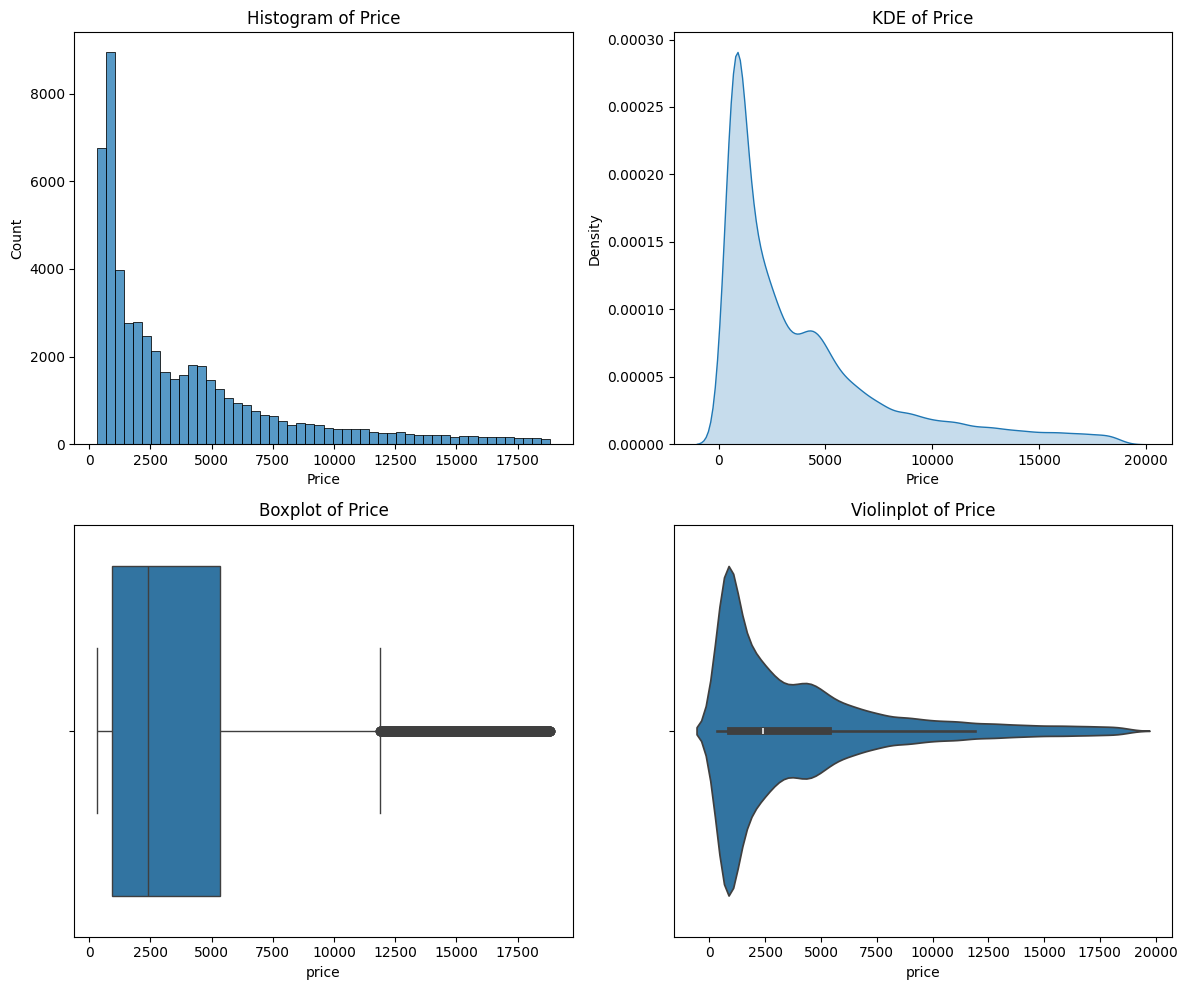

In [14]:
# ЗАДАНИЕ:
#          1. Постройте 4 типа визуализации для столбца 'price'.
#          2. Подтвердите (или опровергните) выводы предыдущих пунктов о распределениях других столбцов.
#          3. Напишите итоговый вывод о распределении данных.

plt.figure(figsize=(12,10))

# 1 гистограмма
plt.subplot(2,2,1)
sns.histplot(diamonds['price'], bins=50)
plt.title("Histogram of Price")
plt.xlabel("Price")

# 2 KDE
plt.subplot(2,2,2)
sns.kdeplot(diamonds['price'], fill=True)
plt.title("KDE of Price")
plt.xlabel("Price")

# 3 Boxplot
plt.subplot(2,2,3)
sns.boxplot(x=diamonds['price'])
plt.title("Boxplot of Price")

# 4 Violinplot
plt.subplot(2,2,4)
sns.violinplot(x=diamonds['price'])
plt.title("Violinplot of Price")

plt.tight_layout()
plt.show()

_Какой график лучше всего показывает асимметрию распределения? Какой график лучше выявляет выбросы? Почему для цен бриллиантов медиана — более репрезентативная мера, чем среднее?_

"Подтвердите (или опровергните) выводы предыдущих пунктов о распределениях других столбцов". Я не очень поняла этот пункт, как по графикам столбца price можно сделать какие-то выводы о других распределениях?



**Асимметрия распределения:**  
- Гистограмма и KDE-график показывают, что распределение цен правостороннее.  
- Большинство бриллиантов имеют низкую цену, а несколько очень дорогих камней образуют длинный правый хвост.

**Выбросы:**  
- Boxplot наглядно показывает множество выбросов в сторону высоких цен.  
- Эти выбросы соответствуют редким, но очень дорогим камням.

**Мера центральной тенденции:**  
- Среднее значение `price` сильно искажено наличием редких дорогих камней.  
- Медиана является более репрезентативной: она отражает типичную цену большинства бриллиантов, игнорируя экстремальные значения.

**Вывод:**  
- Для анализа цен бриллиантов медиана — надежная мера центральной тенденции.  
- Гистограмма и KDE помогают увидеть асимметрию распределения, а boxplot выявляет выбросы.  
- Большинство камней недорогие, и только небольшое число дорогих сильно влияет на среднее значение.

### Двумерный анализ (2 pt)

После того, как вы подробно изучили распределение каждого из признаков, перейдем к изучению «влияния» признаков друг на друга. 

**Двумерный анализ** — анализ взаимосвязи призваков друг с другом.  
Самым простым подходом является анализ **распределения одного признака в зависимости от значения другого** (например распределение цены для разной огранки), однако вы уже должны быть способны это сделать (условная фильтрация в pandas + визуализация распределения), поэтому останавливаться на этом мы сейчас не будем. _Но обязательно примените этот анализ во второй части!_

***

В этом задании остановимся на анализе **корреляций** признаков. Важно помнить, что **корреляция $\neq$ причинно-следственная связь**! Корреляция измеряет силу и направление связи между двумя числовыми признаками.

**Будем рассматривать два типа корреляции** (подробнее про [корреляцию](https://ru.wikipedia.org/wiki/%D0%9A%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D1%8F) в интренетах или на матстате):

| Тип корреляции | Что это такое | Когда использовать |
| -------------- | -------------- | ------------------ |
| **Пирсона** | 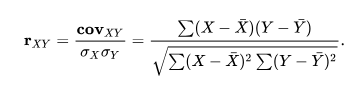 | Для линейных связей в нормально распределенных данных |
| **Спирмена** | Корреляция рангов | Для монотонных (не обязательно линейных) связей, устойчива к выбросам |

Документация: [.corr()](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.corr.html),
[.spearmanr()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html).

Корреляцию можно интерпретировать по-разному (разные градации/шкалы), но в целом логика такая: чем больше, тем сильнее величины связаны, если знак отрицательный, то «рост» одной связан с «падением» другой.

In [15]:
# Нетрудно заметить, что корреляция работает только для числовых признаков,
# поэтому выберем только числовые столбцы из данных

numeric_diamonds = diamonds.select_dtypes(include=[np.number])

# ЗАДАНИЕ:
#          1. Рассчитайте матрицу корреляций Пирсона для числовых признаков
#          2. Найдите пару признаков с самой сильной положительной корреляцией
#          3. Рассчитайте корреляцию Спирмена для этой же пары признаков
#          4. Сравните значения Пирсона и Спирмена — отличаются ли они, почему?

# Матрица корреляций Пирсона
pearson_corr = numeric_diamonds.corr(method='pearson')
print("Матрица корреляций Пирсона:\n", pearson_corr)

# Находим пару признаков с самой сильной положительной корреляцией
# удаляем диагональ, чтобы не учитывать корреляцию признака с самим собой
pearson_corr_no_diag = pearson_corr.where(~np.eye(pearson_corr.shape[0],dtype=bool))
max_corr = pearson_corr_no_diag.stack().idxmax()  # кортеж вида (feature1, feature2)
print("\nПара признаков с самой сильной положительной корреляцией:", max_corr)
print("Значение корреляции Пирсона:", pearson_corr.loc[max_corr])

#  Рассчитаем корреляцию Спирмена для этой же пары признаков
spearman_corr = numeric_diamonds[list(max_corr)].corr(method='spearman')
print("\nМатрица корреляции Спирмена для этой пары:\n", spearman_corr)

# Сравниваем значения
pearson_value = pearson_corr.loc[max_corr]
spearman_value = spearman_corr.loc[max_corr[0], max_corr[1]]

print(f"\nСравнение Пирсона ({pearson_value:.3f}) и Спирмена ({spearman_value:.3f}) для признаков {max_corr}:")


Матрица корреляций Пирсона:
           carat     depth     table     price         x         y         z
carat  1.000000  0.027861  0.181091  0.921548  0.977713  0.953857  0.960404
depth  0.027861  1.000000 -0.297669 -0.011048 -0.025301 -0.029332  0.094645
table  0.181091 -0.297669  1.000000  0.126566  0.195433  0.183792  0.151626
price  0.921548 -0.011048  0.126566  1.000000  0.886906  0.867471  0.867392
x      0.977713 -0.025301  0.195433  0.886906  1.000000  0.974831  0.975052
y      0.953857 -0.029332  0.183792  0.867471  0.974831  1.000000  0.956323
z      0.960404  0.094645  0.151626  0.867392  0.975052  0.956323  1.000000

Пара признаков с самой сильной положительной корреляцией: ('carat', 'x')
Значение корреляции Пирсона: 0.9777131137963041

Матрица корреляции Спирмена для этой пары:
           carat         x
carat  1.000000  0.996579
x      0.996579  1.000000

Сравнение Пирсона (0.978) и Спирмена (0.997) для признаков ('carat', 'x'):


Самая сильная корреляция между carat и x, то есть между весом и длиной, это логично и не очень интересно, интереснее посмотреть на зависимость carat и price. 

In [16]:
# Выбираем только числовые столбцы
numeric_diamonds = diamonds.select_dtypes(include=[np.number])

# Корреляция Пирсона
pearson_value = numeric_diamonds['carat'].corr(numeric_diamonds['price'], method='pearson')
print(f"Корреляция Пирсона между carat и price: {pearson_value:.3f}")

# Корреляция Спирмена через DataFrame (обход scipy)
spearman_value = numeric_diamonds[['carat', 'price']].rank().corr().iloc[0,1]
print(f"Корреляция Спирмена между carat и price: {spearman_value:.3f}")



Корреляция Пирсона между carat и price: 0.922
Корреляция Спирмена между carat и price: 0.963


у веса и длины почти линейная монотонная зависимость, тоже самое у веса и цены

**Ответ:** 
**Вывод по матрице корреляций:**

- Наибольшая положительная корреляция наблюдается между `carat` и `x` (0.975), а также `carat` и `y`/`z` (0.95–0.95). Это говорит о том, что размер камня (длина, ширина, высота) тесно связан с его весом.
- Цена (`price`) сильно коррелирует с весом (`carat`) — 0.922, а также с размерами (`x`, `y`, `z`) — 0.86–0.88. Это подтверждает, что увеличение веса и размера почти всегда сопровождается ростом цены.
- Признаки `depth` и `table` практически не коррелируют с другими признаками и ценой, что указывает на то, что они отражают скорее качество огранки, чем размер или стоимость.


**Итог:**  
Вес и размеры камня — ключевые факторы, определяющие цену. Качество огранки (`depth`, `table`) имеет слабое влияние на цену.

***
Оперировать числами довольно сложно, можно что-то пропустить. Как и написано в замечании в предыдущем разделе, проще «увидеть» гипотезы на картинке и уже числами их подтвердить. На помощь для двумерного анализа приходят новые типы графиков.

| Тип графика | Что показывает | Когда использовать | Ограничения | 
| ---------- | ------- | -------- | ------------- |
| **Heatmap** (тепловая карта) | Матрицу значений через цветовую кодировку | Быстрый обзор всех парных связей в числовых данных <br>Поиск сильных корреляций <br>Визуализация пропусков (`sns.heatmap(df.isna())`) |  Не показывает форму связи (линейная/нелинейная) <br>Трудно интерпретировать при >15 признаках |
| **Scatter plot** (точечная диаграмма) | Двумерное распределение точек | Анализ конкретной пары признаков <br>Проверка гипотезы о связи (напр., цена vs карат) <br>Визуализация категорий через цвет (`hue`) | Показывает только 2 признака за раз (+1 категориальный через `hue`) <br>Перекрытие точек при больших данных (`alpha` помогает) |
| **Pairplot** (матрица scatter plot) | Все попарные комбинации числовых признаков <br>Распределение на диагонали (гистограмма/KDE) | Быстрый обзор взаимосвязей в небольших датасетах (<10 признаков) <br>Поиск интересных пар для детального анализа | Квадратичная сложность: 10 признаков = 100 графиков! <br>Перегружен при большом количестве данных и долго считается |

Во всех этих графиках важна **настройка параметров** (иногда даже цветовая гпмма может влиять на интерпретируемость), поэтому внимательно посмотрите в документацию: [sns.heatmap()](https://seaborn.pydata.org/generated/seaborn.heatmap.html),
[sns.scatterplot()](https://seaborn.pydata.org/generated/seaborn.scatterplot.html),
[sns.pairplot()](https://seaborn.pydata.org/generated/seaborn.pairplot.html).

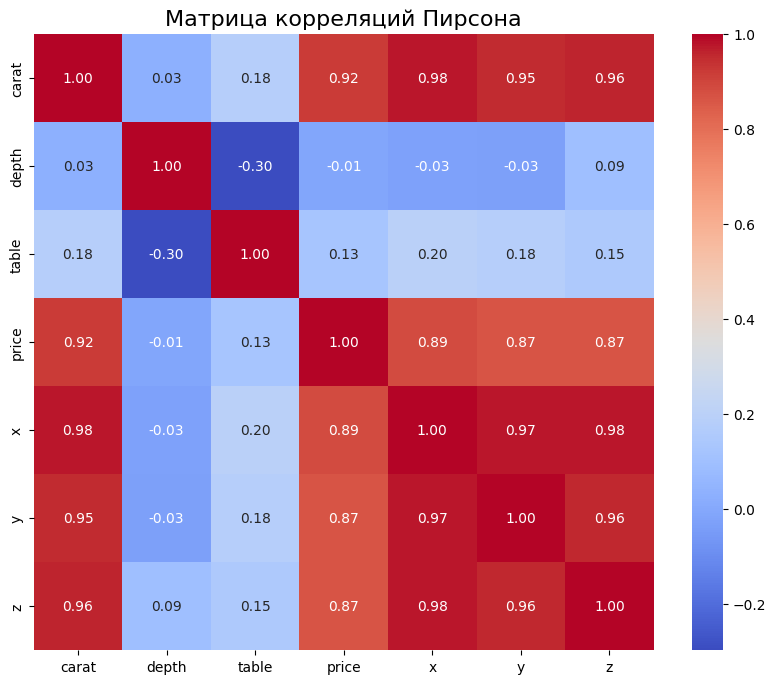

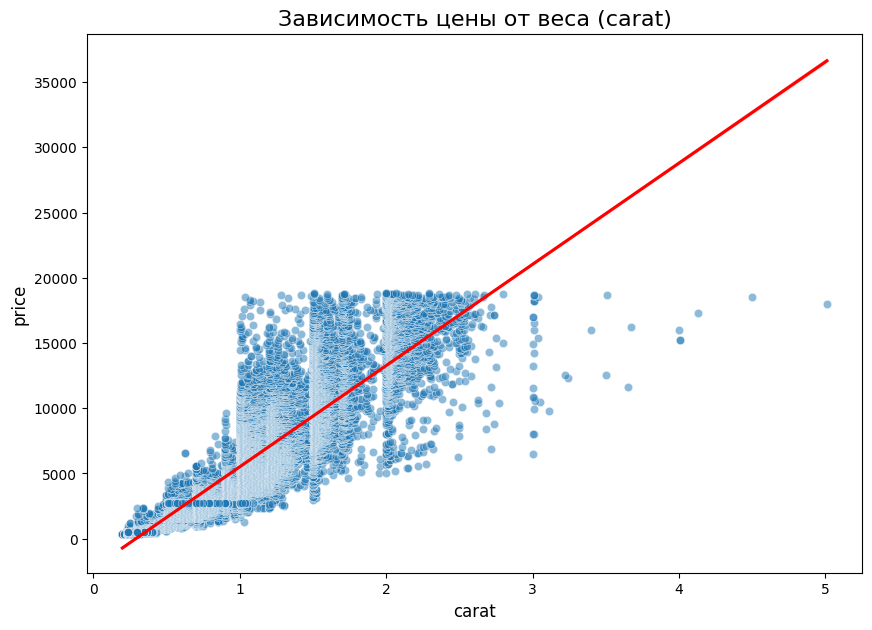

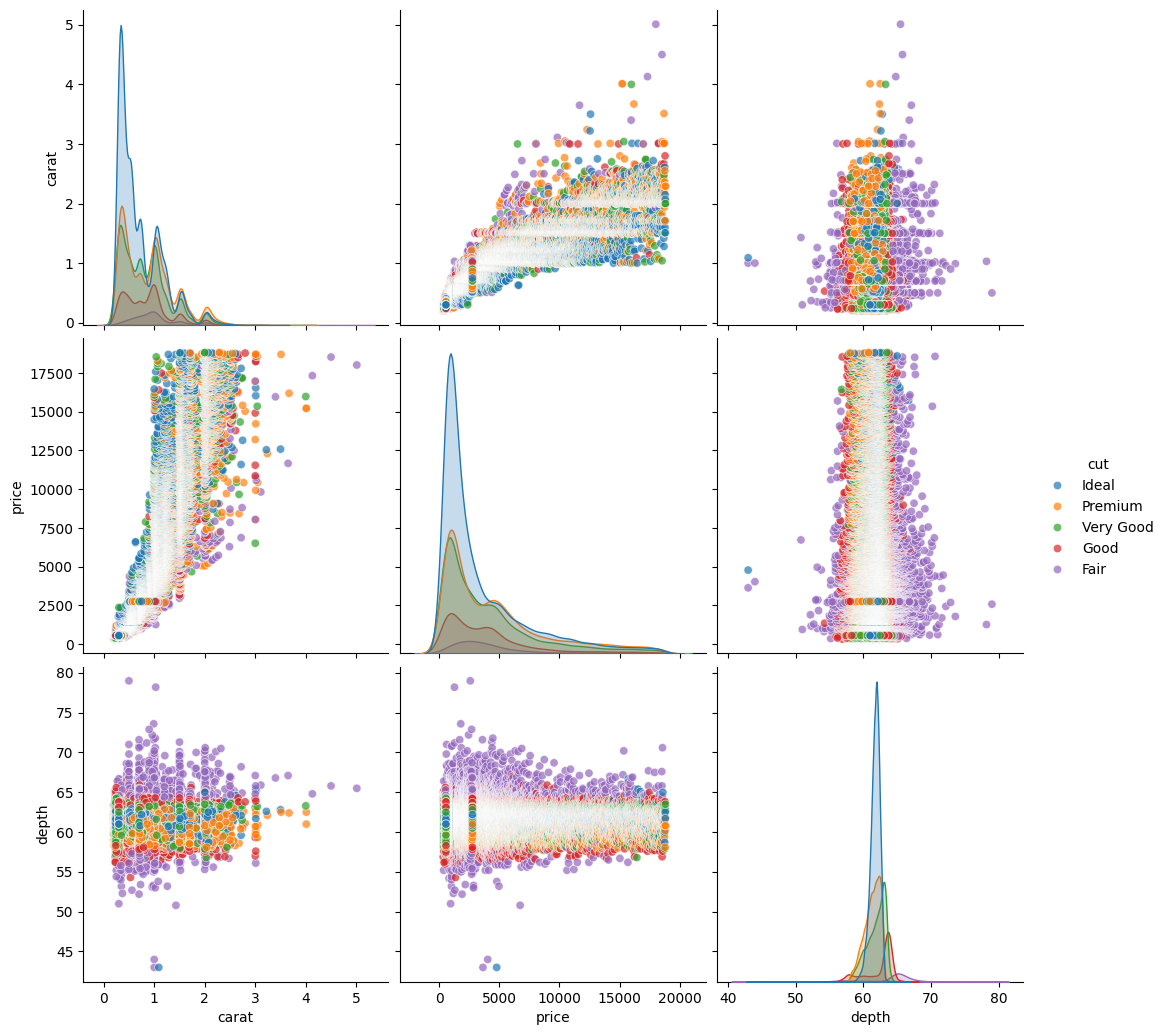

In [17]:
# ЗАДАНИЕ:
#          1. Постройте тепловую карту (heatmap) матрицы корреляций Пирсона
#          2. Постройте scatter plot для пары признаков с максимальной корреляцией
#             - Добавьте линию регрессии (sns.regplot)
#          3. Постройте pairplot для признаков ['carat', 'price', 'depth'] с цветовым разделением по 'cut'

# 1. Тепловая карта матрицы корреляций Пирсона
plt.figure(figsize=(10,8))  
sns.heatmap(numeric_diamonds.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матрица корреляций Пирсона", fontsize=16)
plt.show()


# 2. Scatter plot для пары с максимальной корреляцией (
plt.figure(figsize=(10,7)) 
sns.scatterplot(data=numeric_diamonds, x='carat', y='price', alpha=0.5)
sns.regplot(data=numeric_diamonds, x='carat', y='price', scatter=False, color='red')
plt.title("Зависимость цены от веса (carat)", fontsize=16)
plt.xlabel("carat", fontsize=12)
plt.ylabel("price", fontsize=12)
plt.show()


# 3. Pairplot для ['carat', 'price', 'depth'] с цветом по 'cut'
# увеличим размер каждого графика через height
sns.pairplot(diamonds, vars=['carat', 'price', 'depth'], hue='cut', plot_kws={'alpha':0.7}, height=3.5)
plt.show()

**ВЫВОД:** 

**Вывод по зависимости цены от веса (carat):**

- Наблюдается **сильная положительная зависимость**: с увеличением веса камня цена растёт.  
- Большинство камней сосредоточено в диапазоне `carat` до ~2, где цены умеренные.  
- Для крупных камней (`carat` > 2) точки разрежены и наблюдаются **выбросы** с очень высокой ценой.  
- На графике видны **горизонтальные полосы точек**, что связано с округлением цены (моя гипотеза)
- Распределение цен **правосторонне скошено**: среднее выше медианы, что объясняется редкими дорогими крупными камнями. 
- Выбросы - есть отдельные точки с очень высокой ценой при большом carat (>3), они выделяются из основной массы — это редкие крупные камни.


## Анализ scatter plot для пары признаков

### 1. Carat × Price × Cut
- **Выбросы:**  
  На графике явно видны 3 точки с очень высокой ценой и/или большим весом, при этом у них плохая огранка.  
- **Общее скопление:**  
  - Для крупных и дорогих камней фиолетовых точек (плохая огранка) почти нет → крупные алмазы обычно имеют хорошую огранку.  
  - Для алмазов с меньшей ценой встречается больше камней с плохой огранкой.  
- **Вывод:**  
  - Цена определяется **тремя основными факторами**: вес (carat), качество огранки (cut) и, косвенно, глубина (depth).  
  - Выбросы показывают, что у крупных камней иногда встречается плохая огранка, но это не нарушает общую закономерность.

---

### 2. Carat × Depth × Cut
- **Визуализация:**  
  На scatter plot сложно увидеть явные зависимости.  
- **Вывод:**  
  - Глубина (depth) не показывает чёткой связи с весом или качеством огранки.  
  - **Глубина влияет на цену менее явно**, чем carat и cut.

---

### 3. Price × Depth
- **Визуализация:**  
  На графике нет явных группировок или выбросов.  
- **Вывод:**  
  - Цена не имеет прямой зависимости от глубины.  
  - Любые закономерности в цене скорее объясняются **весом (carat) и огранкой (cut)**, а не depth.



### Дополнительное задание (1+ pt)

Проанализируйте влияние категориального признака `cut` (качество огранки) на распределение цены бриллиантов.

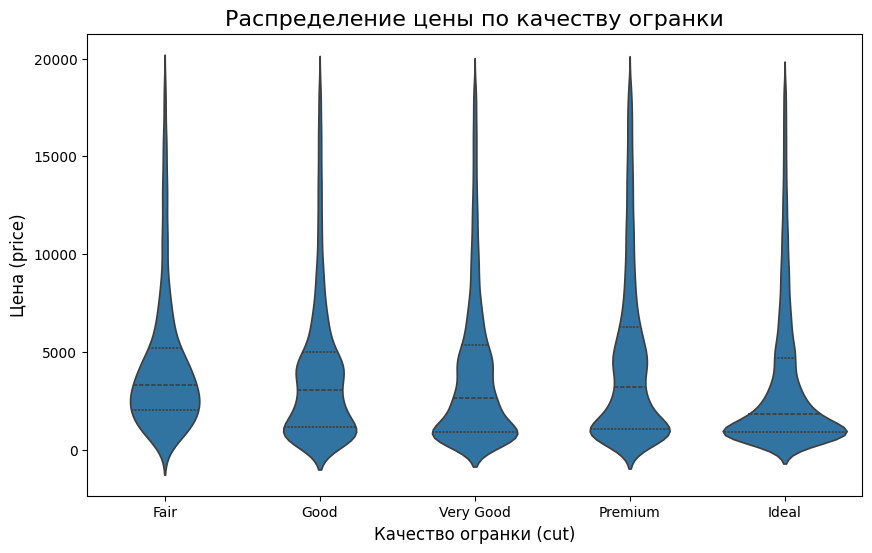

In [18]:
plt.figure(figsize=(10,6))
sns.violinplot(data=diamonds, x='cut', y='price', order=['Fair','Good','Very Good','Premium','Ideal'], inner='quartile')
plt.title("Распределение цены по качеству огранки", fontsize=16)
plt.xlabel("Качество огранки (cut)", fontsize=12)
plt.ylabel("Цена (price)", fontsize=12)
plt.show()

Тут видно что в каждом ценовом сегменте есть и плохо ограненные и хорошо ограненные камни. У меня была гипотеза, что дорогие камни будут хорошо огранены, но это оказалось не так. у огранки "ideal" цены сосредоточены вообще ниже 5000, у good видно две моды - почти 5000 и ниже 2500. 

<Axes: xlabel='cut', ylabel='price'>

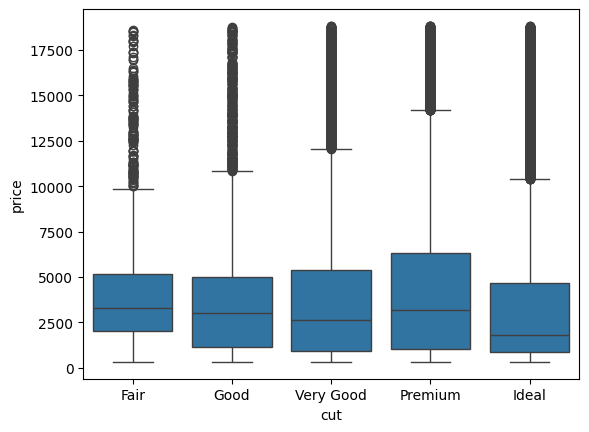

In [19]:
sns.boxplot(data=diamonds, x='cut', y='price', order=['Fair','Good','Very Good','Premium','Ideal'])

вот boxplot оказался более информативным: видно межквартильный размах, он у всех сосредоточен примерно от 1500 7500, усы тоже довольно интересные, есть данные, которые сильно расходятся от основной массы, но не выбросы. А выбросов вроде нет, не понятно у Fair скопление точек это выбросы или усы. Но мне все же кажется, что это усы. 

**Вывод**

- На каждом ценовом сегменте встречаются как плохо ограненные, так и хорошо ограненные камни.  
  - Гипотеза, что дорогие камни будут исключительно с хорошей огранкой, **не подтвердилась**.  

- **Особенности распределений по категориям `cut`:**  
  - `Ideal` — большинство цен сосредоточено ниже 5000.  
  - `Good` — видно **две моды**: около 5000 и ниже 2500.  
  - Межквартильный размах для всех категорий примерно одинаков: **1500–7500**, что показывает основную массу данных.  

- **Усы и выбросы:**  
  - Усы показывают, что есть данные, сильно расходящиеся от основной массы, но не выбросы.  
  - Для категории `Fair` скопление точек скорее всего **часть усов**, а не выбросы.  

- **Вывод по типу зависимости:**  
  - Зависимость цены от огранки есть, но **не строгая линейная или прямая связь**.  
  - Цена определяется **несколькими факторами одновременно** (вес, глубина, огранка).  
  - Boxplot оказался **очень информативным**, так как показал медиану, межквартильный размах и распределение точек, включая «разброс» данных.  

**Итог:** качество огранки влияет на распределение цены, но **не является единственным определяющим фактором и вообще зависимость не очень информативная**, и внутри каждой категории есть широкий диапазон цен.

А еще я поняла, что по-сути огранка уменьшает вес, то есть караты, поэтому может быть что хорошо ограненный камень имеет маленький вес, и при этом он может быть дешевым. То есть это объясняет то, что бриллианты с маленькикими каратами, и, соответсвтенно, маленькими ценами, могут быть хорошо огранены. Но полностью проверить эту гипотезу у меня щас не хватит времени :\ я слишком поздно это поняла.

# Часть 2 (4 pt)

Теперь примените полученные навыки для анализа датасета **Palmer Penguins** — тоже стандартного датасета из `sns`. Этот датасет не такой большой, однако в нем можно найти интересные закономерности и больше узнать о пингвинчиках)

In [20]:
penguins = sns.load_dataset('penguins')
penguins.shape

(344, 7)

***
**ЗАДАНИЕ:** Проведите полный EDA датасета penguins.  
Для это проведите
* базовое **знакомство и чистку** данных (обосновывайте ваши действия),
* **одномерный анализ** всех признаков,
* **двумерный анализ** (не только корреляции, но и распределение при значениях других признаков),
* а также **сформулируйте 3 неочевидных вывода**, подкреплённых **статистикой/визуализацией**.

**Сначала начнем с базовых действий: посмотреть и обработать пропуски, дубликаты**

In [21]:
penguins.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


Базовый анализ первых 10-ти строк: видно, что в длине клюва и прочих размерах есть пропуски, их можно запонить медианой. А вот с полом будет сложнее, не понятно пока как его заполнять, ведь это сильно отразится на статистике, может их просто удалять? Но строк итак мало, всего около 344. Скорее всего надо будет брать медиану по острову и по сорту пингивина, или по весу. Также видно, что есть полностью пустые строки, их надо дропнуть. 

In [22]:
num_duplicates = penguins.duplicated(keep=False).sum()
print(f"Количество полностью повторяющихся строк: {num_duplicates}")


Количество полностью повторяющихся строк: 0


In [23]:
# общее количество столбцов
num_cols = penguins.shape[1]

# количество NaN по каждой строке
nan_per_row = penguins.isna().sum(axis=1)

# условие: NaN больше половины столбцов
rows_too_many_nan = nan_per_row > (num_cols / 2)

rows_with_too_many_nan = penguins[rows_too_many_nan]
print(rows_with_too_many_nan)
# удаляем строки, где NaN больше половины столбцов
penguins_clean = penguins[nan_per_row <= (num_cols / 2)]

# проверим результат
print(f"Размер датасета после удаления строк: {penguins_clean.shape}")

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
3    Adelie  Torgersen             NaN            NaN                NaN   
339  Gentoo     Biscoe             NaN            NaN                NaN   

     body_mass_g  sex  
3            NaN  NaN  
339          NaN  NaN  
Размер датасета после удаления строк: (342, 7)


In [24]:

numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# заполняем пропуски медианой по каждому столбцу
penguins[numeric_cols] = penguins[numeric_cols].fillna(penguins[numeric_cols].median())

# проверим результат
print(penguins[numeric_cols].isna().sum())

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


In [25]:
# заполняем NaN в 'sex' по моде внутри каждого вида
penguins['sex'] = penguins.groupby('species')['sex'].transform(lambda x: x.fillna(x.mode()[0]))

# проверим, остались ли NaN
print(penguins['sex'].isna().sum())

0


Таким образом я базово обработала датасет: заполнила пропуски, убрала строки, где Nan больше половины, таких строк было всего две. 

**1. Одномерный анализ**
1.1 Числовые признаки

Столбцы:
bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g

я только потом, когда уже вернулась к графикам из прошлого датасета, вспомнила, что сначлала мы строим графики и выдвигаем гипотезы, а потом численно подтверждаем их всякими разбрсами, но тут я в другом порядке сделала... но теперь я точно запомнила, как надо 

In [26]:
print("базовые характеристики:\n")
penguins.describe() 


базовые характеристики:



,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,344.000000,344.000000,344.000000,344.000000
mean,43.925000,17.152035,200.892442,4200.872093
std,5.443792,1.969060,14.023826,799.696532
min,32.100000,13.100000,172.000000,2700.000000
25%,39.275000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


из базовых характеристик видно, что по всем значениям медиана не сильно отличается от среднего, почти наверняка выбросов нет. 

In [27]:
# выбираем только числовые столбцы
numeric_cols = penguins.select_dtypes(include='number')

# дисперсия
variance = numeric_cols.var()

# стандартное отклонение
std_dev = numeric_cols.std()

# квартиль 1 и 3
q1 = numeric_cols.quantile(0.25)
q3 = numeric_cols.quantile(0.75)

# межквартильный размах
iqr = q3 - q1

# асимметрия
skewness = numeric_cols.skew()

# эксцесс
kurt = numeric_cols.kurtosis()

print("Дисперсия:\n", variance)
print("\nСтандартное отклонение:\n", std_dev)
print("\nIQR:\n", iqr)
print("\nАсимметрия:\n", skewness)
print("\nЭксцесс:\n", kurt)

Дисперсия:
 bill_length_mm           29.634869
bill_depth_mm             3.877197
flipper_length_mm       196.667698
body_mass_g          639514.543359
dtype: float64

Стандартное отклонение:
 bill_length_mm         5.443792
bill_depth_mm          1.969060
flipper_length_mm     14.023826
body_mass_g          799.696532
dtype: float64

IQR:
 bill_length_mm          9.225
bill_depth_mm           3.100
flipper_length_mm      23.000
body_mass_g          1200.000
dtype: float64

Асимметрия:
 bill_length_mm       0.051571
bill_depth_mm       -0.145196
flipper_length_mm    0.351218
body_mass_g          0.474832
dtype: float64

Эксцесс:
 bill_length_mm      -0.863835
bill_depth_mm       -0.894380
flipper_length_mm   -0.971878
body_mass_g         -0.704620
dtype: float64


**Общий вывод по разбросу и распределению числовых признаков**

На основе анализа дисперсии, стандартного отклонения, межквартильного размаха, асимметрии и эксцесса можно сделать следующие выводы:

Разброс данных:
Наибольший разброс наблюдается у массы пингвинов (body_mass_g) и длины ласт (flipper_length_mm), что отражает значительные различия между видами и размерами особей. Клюв по длине и глубине (bill_length_mm, bill_depth_mm) более стабильный и имеет меньший разброс.

Форма распределения:
Все признаки имеют почти симметричное или слегка правосторонне смещённое распределение. Эксцесс отрицательный для всех признаков, что указывает на плосковершинное распределение — значения распределены относительно равномерно вокруг среднего, без острых пиков.

Центральные значения:
Медиана и среднее значения близки друг к другу для большинства признаков, что говорит о том, что распределения не сильно искажены выбросами. Для массы и длины ласт среднее немного выше медианы, что отражает наличие более крупных или тяжёлых особей.

Итог:
Данные демонстрируют умеренный разброс с лёгкой асимметрией у некоторых признаков, при этом клюв более однородный, а масса и ласты — нет. 
Но вообще надо это все нарисовать, чтобы наглядно было. 

In [28]:
penguins.describe(include='object')


C:\Users\pochi\AppData\Local\Temp\ipykernel_20732\3425964429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  penguins.describe(include='object')


,species,island,sex
count,344,344,344
unique,3,3,2
top,Adelie,Biscoe,Male
freq,152,168,173


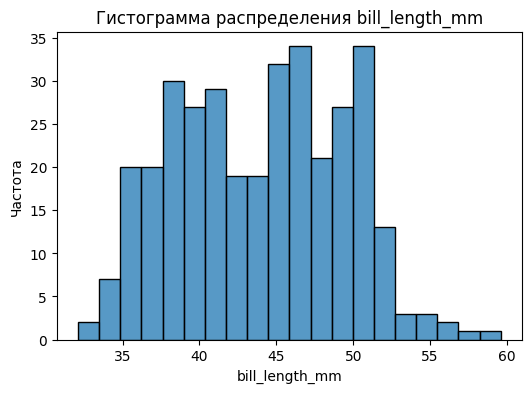

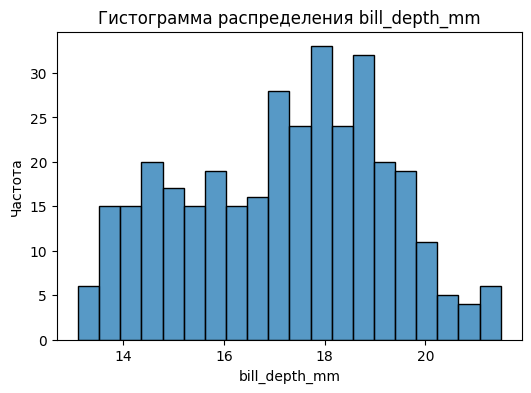

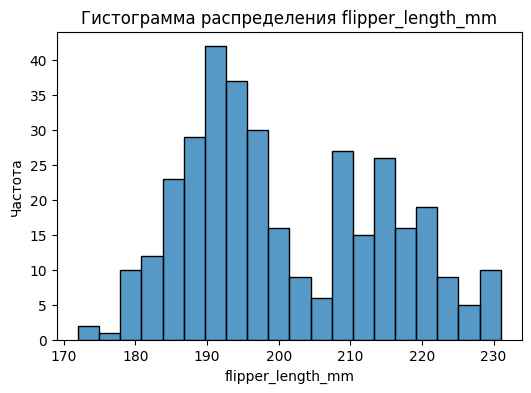

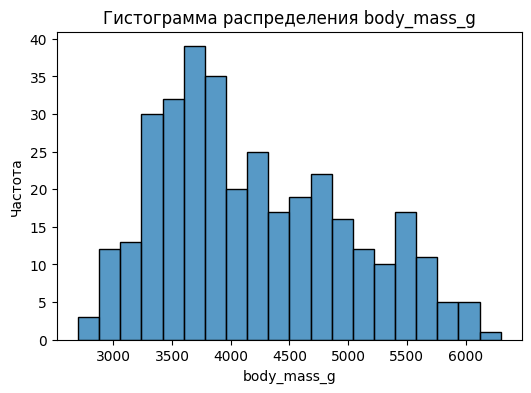

In [29]:
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(data=penguins, x=col, bins=20)
    plt.title(f'Гистограмма распределения {col}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.show()

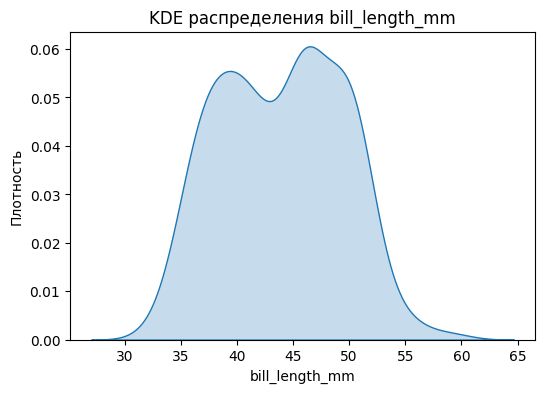

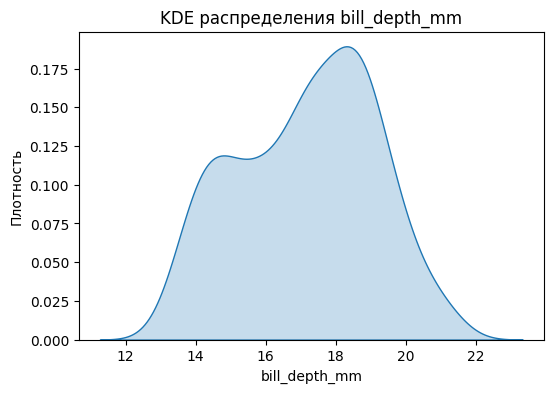

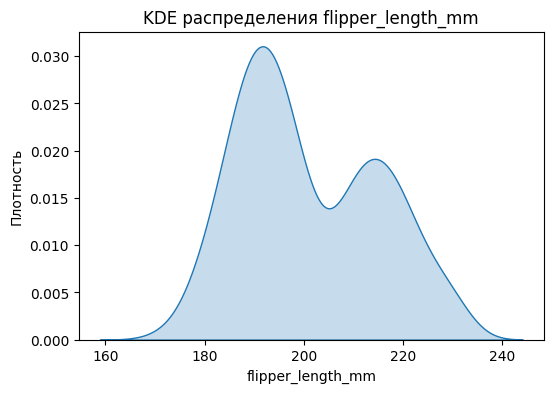

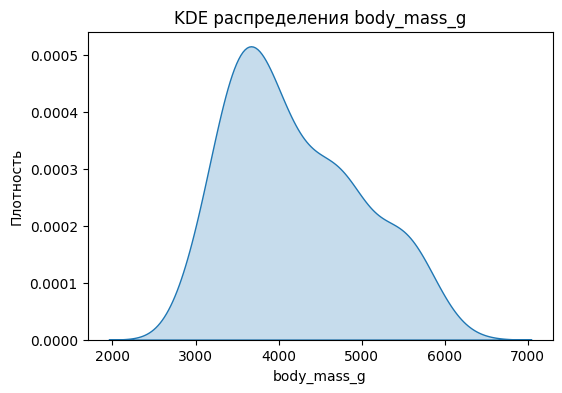

In [30]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=penguins, x=col, fill=True)
    plt.title(f'KDE распределения {col}')
    plt.xlabel(col)
    plt.ylabel('Плотность')
    plt.show()

Видно что в длине клюва есть два пика - это около 37 и около 45, наверное, это зависит от пола. Надо будет проверить эту гипотезу.

Глубина около 14.2 и 17, тоже вероятно зависит от пола. 

Ласты - 190 и 219, аналогичная гипотеза. 

Масса около 3900. 
Надо посмотеть распределение по полам. 

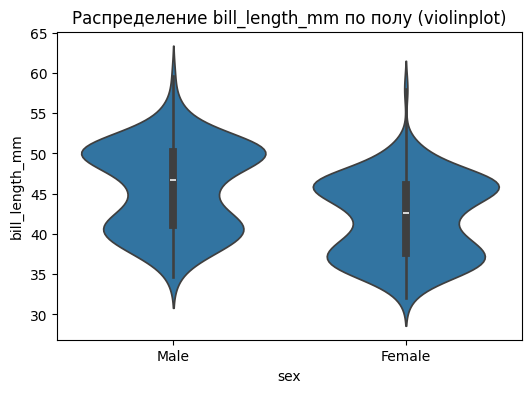

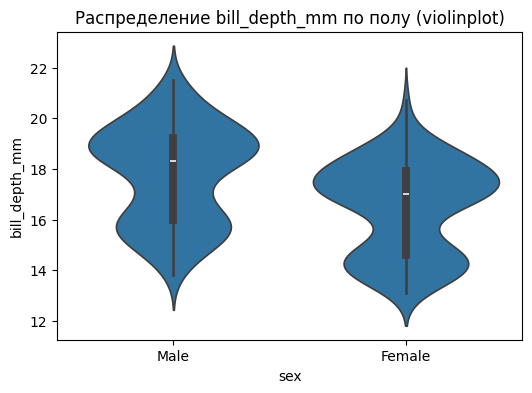

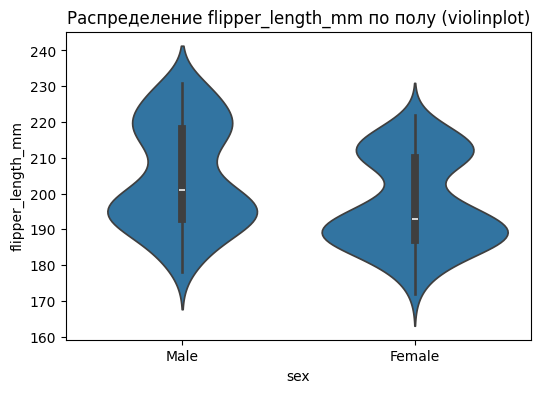

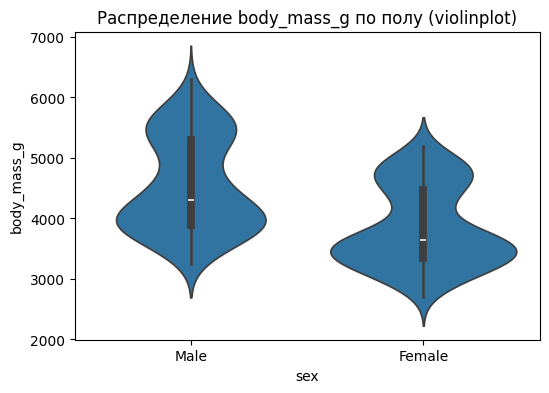

In [31]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(data=penguins, x='sex', y=col)
    plt.title(f'Распределение {col} по полу (violinplot)')
    plt.show()

Гипотеза не подтвердилась: видно, что для каждого пола есть свои пики, наверное, это связано с видом или средой обитание, позже надо будет это посмотреть в двумерном анализе.

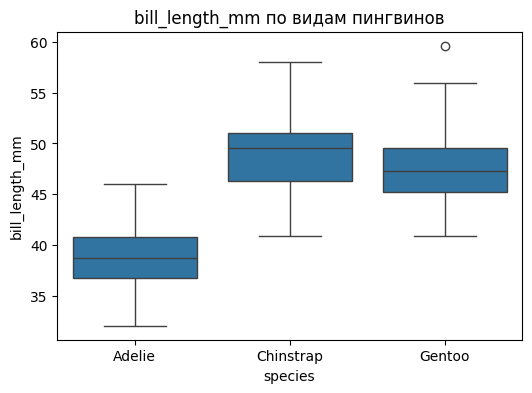

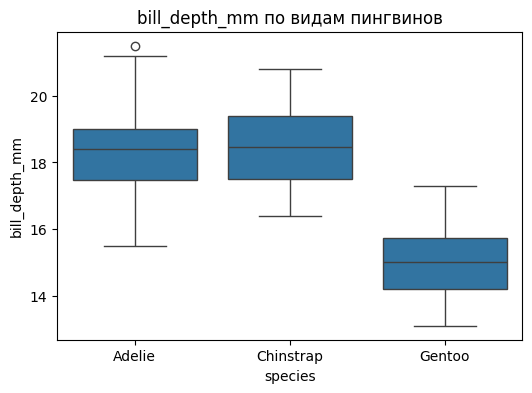

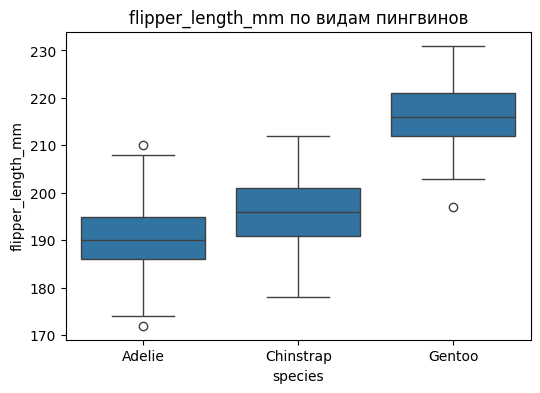

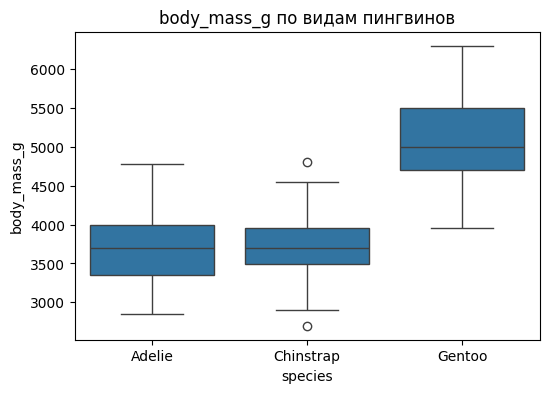

In [32]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=penguins, x='species', y=col)
    plt.title(f'{col} по видам пингвинов')
    plt.xlabel('species')
    plt.ylabel(col)
    plt.show()

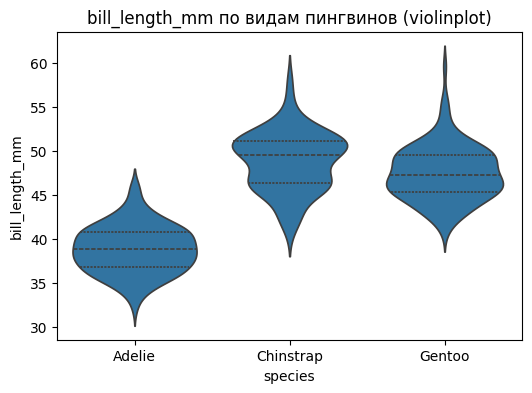

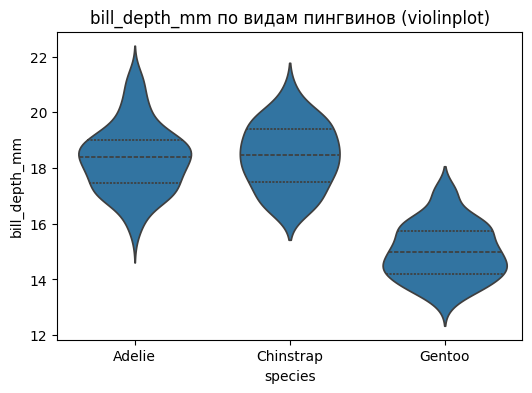

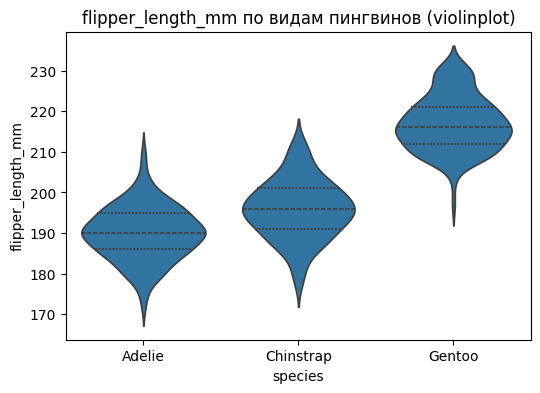

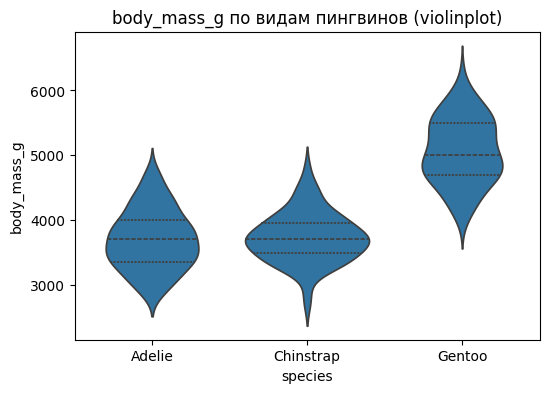

In [33]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.violinplot(data=penguins, x='species', y=col, inner='quartile')
    plt.title(f'{col} по видам пингвинов (violinplot)')
    plt.xlabel('species')
    plt.ylabel(col)
    plt.show()

In [34]:
print("Уникальные острова:", penguins['island'].unique())
print("Уникальные виды пингвинов:", penguins['species'].unique())

Уникальные острова: <StringArray>
['Torgersen', 'Biscoe', 'Dream']
Length: 3, dtype: str
Уникальные виды пингвинов: <StringArray>
['Adelie', 'Chinstrap', 'Gentoo']
Length: 3, dtype: str


Чтобы вручуную не смотерть медиану, межквартильный разброс и тд выведем с помощью кода то, что показывают графики. Но графики все же не бесполезные: по ним мы посмтрим выбросы.

upd: из коробки с усиками видно, что выбросов мало и они в общем то не сильно влияют на данные.

In [35]:


numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Группируем по видам и считаем медиану и IQR
species_summary_median_iqr = penguins.groupby('species')[numeric_cols].apply(
    lambda x: pd.Series({
        'median_bill_length': x['bill_length_mm'].median(),
        'IQR_bill_length': x['bill_length_mm'].quantile(0.75) - x['bill_length_mm'].quantile(0.25),
        'median_bill_depth': x['bill_depth_mm'].median(),
        'IQR_bill_depth': x['bill_depth_mm'].quantile(0.75) - x['bill_depth_mm'].quantile(0.25),
        'median_flipper_length': x['flipper_length_mm'].median(),
        'IQR_flipper_length': x['flipper_length_mm'].quantile(0.75) - x['flipper_length_mm'].quantile(0.25),
        'median_body_mass': x['body_mass_g'].median(),
        'IQR_body_mass': x['body_mass_g'].quantile(0.75) - x['body_mass_g'].quantile(0.25),
    })
)

species_summary_median_iqr

,median_bill_length,IQR_bill_length,median_bill_depth,IQR_bill_depth,median_flipper_length,IQR_flipper_length,median_body_mass,IQR_body_mass
species,,,,,,,,
Adelie,38.80,4.025,18.40,1.525,190.0,9.0,3700.0,650.0
Chinstrap,49.55,4.725,18.45,1.900,196.0,10.0,3700.0,462.5
Gentoo,47.25,4.250,15.00,1.525,216.0,9.0,5000.0,800.0


у меня либо vs code с ума сошел, либо я, поэтому так коряво пришлось все прописывать

In [36]:
# Таблица количества пингвинов по виду и острову
species_island_counts = penguins.groupby(['species', 'island']).size().unstack(fill_value=0)
species_island_counts

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


Вот теперь у нас есть интересные статистики, на основе которых можно строить какие-то гипотезы и проверять их в двумерном анализе. Сначала хочется посмотреть на характеристики климатических условий остравов, чтобы понять, связаны ли как-то характеристики видов со средой обитания. Пока какие-то более интересные гипотезы мне не удается придумать. 

данные из таблички с википедии: 

| Остров           | Климат (погода)                  | Условия пищи (корма)                             |
|------------------|----------------------------------|--------------------------------------------------|
| **Biscoe Island**     | Холодный морской полярный климат; летом около 0 °C, зимой значительно ниже. | Морские воды богаты крилем и рыбой — хороший доступ пищи. |
| **Dream Island**      | Аналогичный морской полярный климат; умеренно холодно, летние температуры около 0 °C. | Побережные воды обеспечивают большое количество криля и мелкой рыбы. |
| **Torgersen Island**  | Холодный антарктический климат; низкие температуры даже летом. | Доступ к кормовым зонам схожий — много криля и планктона.    |

## Я выдвину четыре базовые гипотезы, которые буду проверять с помощью двумерного анализа:

1. Размер пингвинов зависит от вида.

 Почему: по медианным значениям видно, что Gentoo крупнее, чем Adelie и Chinstrap.
 Что проверяем: масса тела, длина ласт, длина клюва.

2. Остров влияет на размеры пингвинов одного вида.
 
 Почему: Adelie встречаются на всех трёх островах, а Gentoo — только на Biscoe, Chinstrap — только на Dream. Возможно, среда обитания влияет на рост.
 Что проверяем: различия в массе тела, длине ласт и клюва у Adelie между островами.

3. Связь между длиной клюва и массой тела зависит от вида.

 Почему: у Gentoo масса тела выше, клюв тоже длиннее.
 Что проверяем: линейная или монотонная зависимость длины клюва и массы тела по видам.

### Проверяем гипотезу 1: для этого мы смотрим на корреляции пирсона и спирмана, переведем виды в числа, чтобы не работать с категориальными данными.

In [37]:
# Присвоим числовые коды видам
species_map = {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}
penguins['species_num'] = penguins['species'].map(species_map)

# Признаки, которые проверяем
features = ['bill_length_mm', 'flipper_length_mm', 'body_mass_g']

# Создадим DataFrame для результатов
results = []

for col in features:
    pearson_corr = penguins[['species_num', col]].corr(method='pearson').iloc[0,1]
    spearman_corr = penguins[['species_num', col]].corr(method='spearman').iloc[0,1]
    results.append({
        'Feature': col,
        'Pearson': pearson_corr,
        'Spearman': spearman_corr
    })

corr_df = pd.DataFrame(results)
print(corr_df)

             Feature   Pearson  Spearman
0     bill_length_mm  0.728706  0.742727
1  flipper_length_mm  0.850819  0.823622
2        body_mass_g  0.747547  0.723144


Все три признака (длина клюва, длина ласт, масса тела) положительно коррелируют с видом пингвинов.

Gentoo — самый крупный вид по всем параметрам, Adelie — самый компактный, Chinstrap — промежуточный.

Корреляции Спирмена и Пирсона близки, что подтверждает как линейную, так и монотонную зависимость.

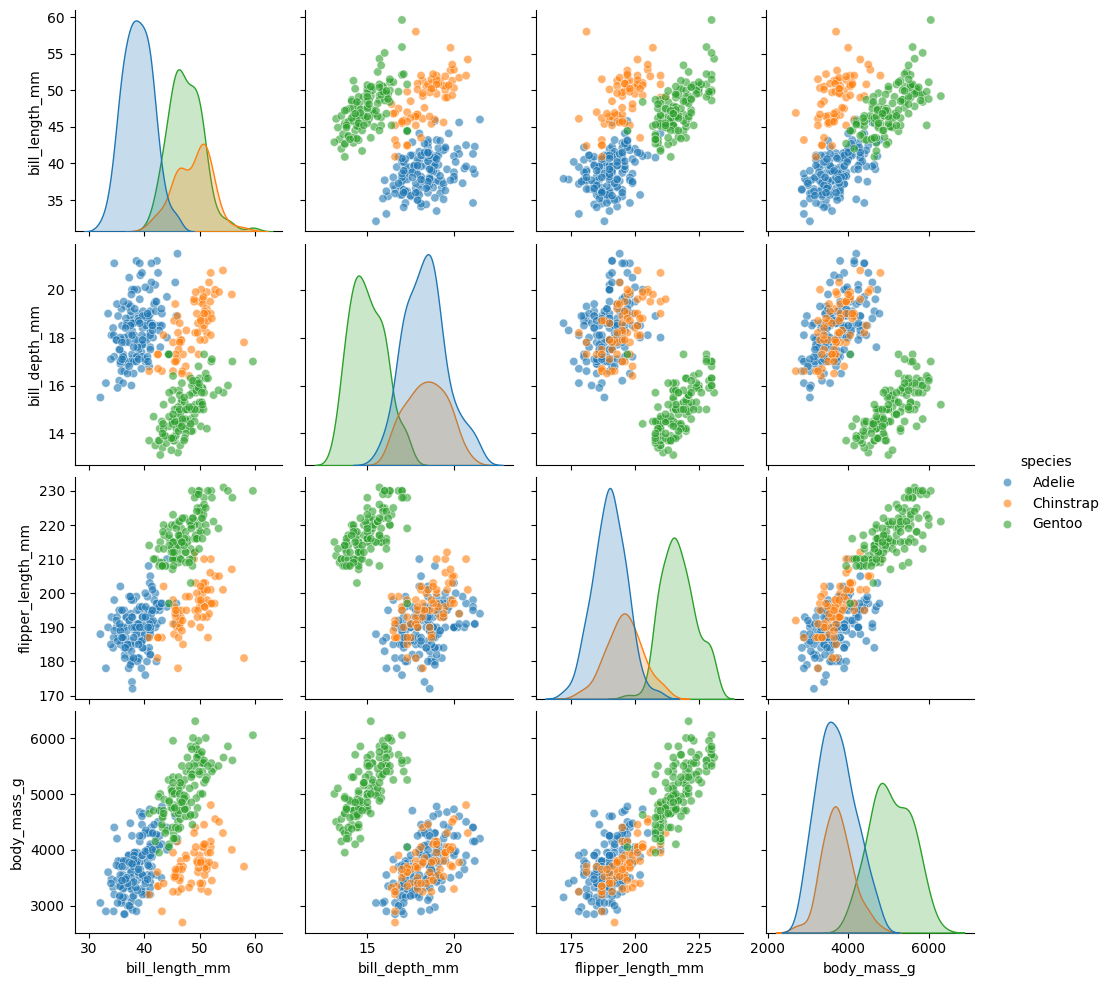

In [38]:
sns.pairplot(penguins, vars=numeric_cols, hue='species', plot_kws={'alpha':0.6})
plt.show()

**Вывод по Гипотезе 1: Размер пингвинов зависит от вида**

Масса тела 
- **Gentoo** явно крупнее всех: медиана массы выше 6000 г, разброс большой 
- **Chinstrap** и **Adelie** значительно легче: медианы около 4000–4200 г.  
- У всех видов есть отдельные выбросы, но общая тенденция ясно показывает различие размеров.  

Длина ласт 
- Gentoo имеет наибольшую длину ласт (197 мм медиана), Adelie и Chinstrap — около 172–178 мм.  
- Разброс у Gentoo больше, что говорит о большей вариативности внутри вида.  
- Форма распределений  показывает, что у Gentoo данные более концентрированы на высоких значениях.  

Длина клюва 
- Gentoo имеет более длинный клюв (14–15 мм медиана) в сравнении с 17–18 мм у Adelie и Chinstrap.  
- Adelie и Chinstrap имеют схожие медианы, но Adelie чуть шире по разбросу.  

Взаимосвязь признаков 
- Визуально видно, что **кластеры по видам не пересекаются сильно**: каждый вид образует отдельное «облако» точек.  
- Масса тела и длина ласт у Gentoo сильнее коррелируют, чем у других видов.  

---

**Общий вывод**
- Гипотеза подтверждается: **размер пингвинов зависит от вида**.  
- Gentoo — крупный вид с наибольшей массой и длиной ласт.  
- Adelie и Chinstrap имеют схожие размеры, но Chinstrap чуть крупнее по ластам и массе.  
- Различия на графиках видны как по медианам, так и по форме распределений.

In [39]:


# Фильтруем только Adelie
adelie = penguins[penguins['species'] == 'Adelie'].copy()

# Присвоим числовые коды островам
island_map = {'Biscoe': 0, 'Dream': 1, 'Torgersen': 2}
adelie['island_num'] = adelie['island'].map(island_map)

# Признаки для проверки
numeric_cols = ['body_mass_g', 'flipper_length_mm', 'bill_length_mm']

# Создаём DataFrame для результатов
results = []

for col in numeric_cols:
    df = adelie[[col, 'island_num']]
    pearson_corr = df.corr(method='pearson').iloc[0,1]
    spearman_corr = df.corr(method='spearman').iloc[0,1]
    results.append({
        'Feature': col,
        'Pearson': pearson_corr,
        'Spearman': spearman_corr
    })

corr_df = pd.DataFrame(results)
print(corr_df)

             Feature   Pearson  Spearman
0        body_mass_g  0.004114 -0.007065
1  flipper_length_mm  0.153941  0.147124
2     bill_length_mm  0.016750  0.004409


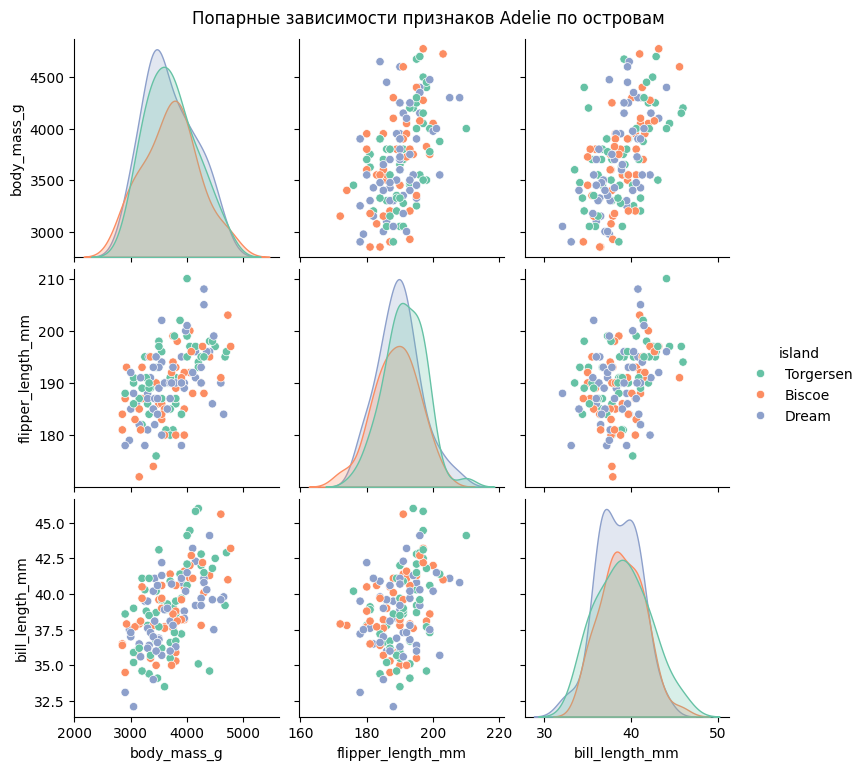

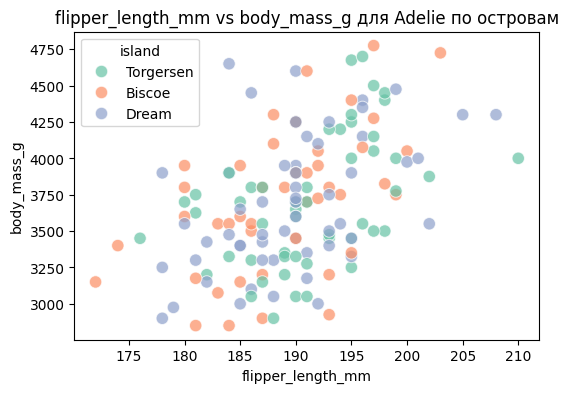

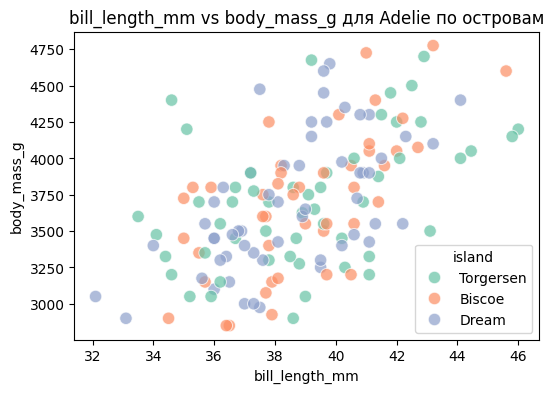

In [40]:

# Признаки для анализа
numeric_cols = ['body_mass_g', 'flipper_length_mm', 'bill_length_mm']

# Pairplot с разным цветом по островам
sns.pairplot(adelie, vars=numeric_cols, hue='island', diag_kind='kde', palette='Set2')
plt.suptitle('Попарные зависимости признаков Adelie по островам', y=1.02)
plt.show()

# Scatterplot для каждого признака против массы тела
for col in ['flipper_length_mm', 'bill_length_mm']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=adelie, x=col, y='body_mass_g', hue='island', palette='Set2', s=80, alpha=0.7)
    plt.title(f'{col} vs body_mass_g для Adelie по островам')
    plt.xlabel(col)
    plt.ylabel('body_mass_g')
    plt.show()

## Вывод по гипотезе 2: Остров влияет на размеры пингвинов одного вида (Adelie)

На графиках (pairplot и scatterplot) видно, что точки по островам практически не формируют отдельные кластеры.

Корреляция между кодами островов и признаками почти нулевая, что подтверждает визуальный вывод.

**Почему так может быть:**

В пределах одного вида размеры пингвинов более обусловлены генетикой, чем различиями в среде обитания.

Климат и условия пищи на трех островах Biscoe, Dream и Torgersen не оказывают заметного влияния на массу или размер тела Adelie.

Меньшие различия между островами могут быть компенсированы адаптацией вида к разным условиям.

**Вывод: гипотеза не подтверждается — для Adelie остров практически не влияет на размеры.**

In [41]:
species_list = penguins['species'].unique()

results = []

for sp in species_list:
    df_sp = penguins[penguins['species'] == sp]

    # Пирсон
    pearson = df_sp['bill_length_mm'].corr(df_sp['body_mass_g'], method='pearson')

    # Спирмен через ранги (без scipy)
    spearman = df_sp['bill_length_mm'].rank().corr(df_sp['body_mass_g'].rank(), method='pearson')

    results.append({
        'species': sp,
        'Pearson': pearson,
        'Spearman': spearman
    })

corr_df = pd.DataFrame(results)
print(corr_df)

     species   Pearson  Spearman
0     Adelie  0.550347  0.553825
1  Chinstrap  0.513638  0.524649
2     Gentoo  0.671631  0.689715


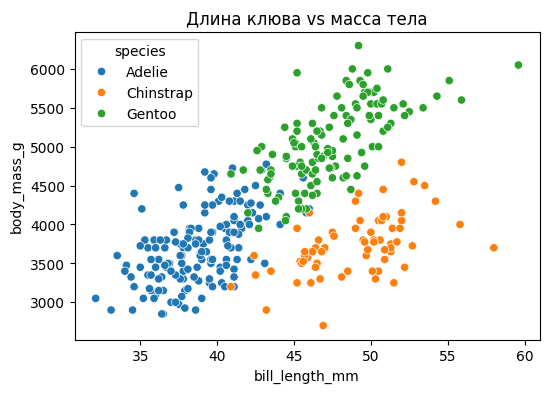

In [42]:

plt.figure(figsize=(6,4))
sns.scatterplot(data=penguins,
                x='bill_length_mm',
                y='body_mass_g',
                hue='species')

plt.title('Длина клюва vs масса тела')
plt.show()

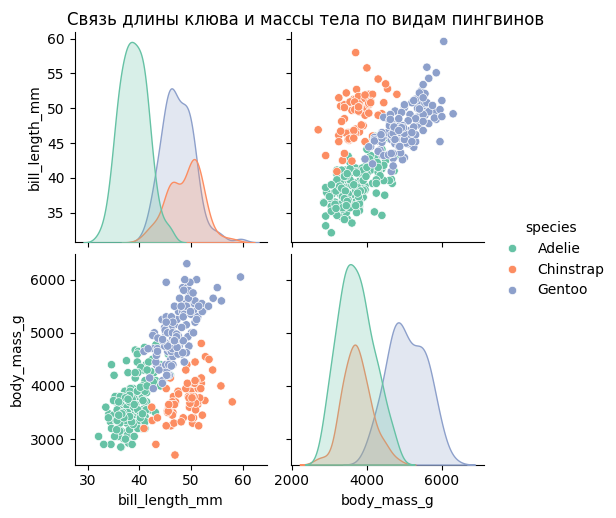

In [43]:
sns.pairplot(
    penguins,
    vars=['bill_length_mm', 'body_mass_g'],
    hue='species',
    diag_kind='kde',
    palette='Set2'
)

plt.suptitle('Связь длины клюва и массы тела по видам пингвинов', y=1.02)
plt.show()

## Проверка гипотезы 3: Связь между длиной клюва и массой тела зависит от вида

Корреляции Пирсона и Спирмена показывают положительную зависимость между длиной клюва и массой тела. Это означает, что в среднем более крупные пингвины имеют более длинный клюв.

На scatterplot и pairplot видно, что точки формируют отдельные кластеры по видам. Gentoo имеют наибольшую массу тела и образуют отдельную группу, тогда как Adelie и Chinstrap располагаются ниже по массе.

**Вывод:** между длиной клюва и массой тела существует положительная зависимость, и она различается между видами. Таким образом, гипотеза подтверждается: более крупные виды пингвинов, как правило, имеют более длинный клюв.

## Общий вывод по анализу данных о пингвинах

В ходе анализа были исследованы различия между видами пингвинов, влияние острова обитания и взаимосвязи между их физическими характеристиками.

Анализ показал, что **размер пингвинов сильно зависит от вида**. Вид Gentoo является самым крупным: у него наибольшая масса тела и длина ласт. Adelie и Chinstrap имеют более похожие размеры и значительно меньше Gentoo.

Гипотеза о влиянии **острова на размеры пингвинов одного вида (Adelie)** не подтвердилась. Корреляции между островом и физическими характеристиками оказались близкими к нулю, а на графиках распределения по островам практически совпадают.

Также была обнаружена **положительная связь между длиной клюва и массой тела**: более крупные пингвины обычно имеют более длинный клюв. На графиках видно, что разные виды формируют отдельные группы, что подтверждает различия между ними.

Таким образом, основной фактор, определяющий размеры пингвинов в данном датасете — **вид**, тогда как влияние острова обитания на размеры внутри одного вида практически не наблюдается.

**УДОСТОВЕРЬТЕСЬ, ЧТО ВСЕ ВАШИ ВЫВОДЫ И КОД ОФОРМЛЕНЫ ТАК, ЧТОБЫ ЛЕГКО МОЖНО БЫЛО ПОНЯТЬ, К ЧЕМУ ОНИ ОТНОСЯТСЯ**  
**НЕ ЗАБУДЬТЕ ПЕРЕЗАПУСТИТЬ НОУТБУК ТАК, ЧТОБЫ ВСЕ ЯЧЕЙКИ БЫЛИ ЗАПУЩЕНЫ ПОДРЯД, НАЧИНАЯ С [1]**